In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col
from pathlib import Path

Path("../figures").mkdir(exist_ok=True)

df = pd.read_parquet("../data/regression_data.parquet")

print(f"Full sample: {len(df)} obs, {df.index[0].date()} to {df.index[-1].date()}")
df.head()

Full sample: 1635 obs, 2018-01-04 to 2024-12-23


,VIX_level,VIX_change,WIG20_next,BUX_next,PX_next,ATX_next
Date,,,,,,
2018-01-04,9.22,0.070001,-0.001430,0.003636,0.000172,0.000124
2018-01-05,9.22,0.000000,0.007507,0.002718,0.003252,-0.000183
2018-01-08,9.52,0.300000,-0.007969,-0.005864,-0.004012,0.002336
2018-01-09,10.08,0.559999,-0.006790,-0.005491,-0.002493,0.009308
2018-01-10,9.82,-0.260000,0.009231,0.003060,0.005386,0.002765


In [2]:
# define the three subperiods
# pre-COVID:     start → 2020-02-15 (before the COVID crash)
# COVID era:     2020-02-15 → 2021-12-31 (crash + recovery)
# post-COVID:    2022-01-01 → end (Russia-Ukraine + normalization)

# we focus on the cleanest pre/post split: pre-COVID vs post-COVID,
# omitting the chaotic transition year of 2020 from comparison
# this gives a clean "stable era 1" vs "stable era 2" comparison

precovid_end    = "2020-02-15"
postcovid_start = "2022-01-01"

pre  = df.loc[:precovid_end]
post = df.loc[postcovid_start:]
full = df.copy()

print("Subperiod definitions:\n")
print(f"  Pre-COVID:   {pre.index[0].date()} → {pre.index[-1].date()}   ({len(pre)} obs)")
print(f"  Post-COVID:  {post.index[0].date()} → {post.index[-1].date()}   ({len(post)} obs)")
print(f"  Full sample: {full.index[0].date()} → {full.index[-1].date()}   ({len(full)} obs)")

Subperiod definitions:

  Pre-COVID:   2018-01-04 → 2020-02-14   (488 obs)
  Post-COVID:  2022-01-03 → 2024-12-23   (702 obs)
  Full sample: 2018-01-04 → 2024-12-23   (1635 obs)


In [3]:
def run_ols(y, X, lags=5):
    X_with_const = sm.add_constant(X)
    return sm.OLS(y, X_with_const).fit(cov_type="HAC", cov_kwds={"maxlags": lags})

markets = ["WIG20", "BUX", "PX", "ATX"]

# run all 12 regressions: 4 markets × 3 subperiods
pre_results  = {}
post_results = {}
full_results = {}

for mkt in markets:
    X_pre  = pre[["VIX_level", "VIX_change"]]
    X_post = post[["VIX_level", "VIX_change"]]
    X_full = full[["VIX_level", "VIX_change"]]
    
    pre_results[mkt]  = run_ols(pre[f"{mkt}_next"],  X_pre)
    post_results[mkt] = run_ols(post[f"{mkt}_next"], X_post)
    full_results[mkt] = run_ols(full[f"{mkt}_next"], X_full)

print("Regressions completed for all four markets × three subperiods.")
print(f"  Pre-COVID:   {len(pre)} observations per regression")
print(f"  Post-COVID:  {len(post)} observations per regression")
print(f"  Full sample: {len(full)} observations per regression")

Regressions completed for all four markets × three subperiods.
  Pre-COVID:   488 observations per regression
  Post-COVID:  702 observations per regression
  Full sample: 1635 observations per regression


In [ ]:
def stars(pval):
    if pval < 0.01: return "***"
    elif pval < 0.05: return "**"
    elif pval < 0.10: return "*"
    else: return ""

rows = []
for mkt in markets:
    pr  = pre_results[mkt]
    po  = post_results[mkt]
    fu  = full_results[mkt]
    
    rows.append({
        "Market"          : mkt,
        "Pre β₂"          : f"{pr.params['VIX_change']:.5f}{stars(pr.pvalues['VIX_change'])}",
        "Pre SE"          : f"({pr.bse['VIX_change']:.5f})",
        "Pre R²"          : f"{pr.rsquared:.4f}",
        "Pre N"           : f"{int(pr.nobs)}",
        "Post β₂"         : f"{po.params['VIX_change']:.5f}{stars(po.pvalues['VIX_change'])}",
        "Post SE"         : f"({po.bse['VIX_change']:.5f})",
        "Post R²"         : f"{po.rsquared:.4f}",
        "Post N"          : f"{int(po.nobs)}",
        "Full β₂"         : f"{fu.params['VIX_change']:.5f}{stars(fu.pvalues['VIX_change'])}",
        "Full R²"         : f"{fu.rsquared:.4f}",
    })

comparison = pd.DataFrame(rows).set_index("Market")
print(comparison.to_string())

comparison.to_csv("../data/table_8_subperiod_analysis.csv")


Table 8: Subperiod Analysis — Pre-COVID vs Post-COVID vs Full Sample
Dependent variable: next-day log return
Newey-West HAC standard errors with 5 lags

             Pre β₂     Pre SE  Pre R² Pre N      Post β₂    Post SE Post R² Post N     Full β₂ Full R²
Market                                                                                                 
WIG20   -0.00145***  (0.00030)  0.0506   488  -0.00134***  (0.00040)  0.0206    702    -0.00080  0.0127
BUX     -0.00146***  (0.00024)  0.0627   488  -0.00125***  (0.00031)  0.0255    702   -0.00076*  0.0176
PX      -0.00108***  (0.00015)  0.0944   488  -0.00069***  (0.00024)  0.0202    702  -0.00065**  0.0250
ATX     -0.00146***  (0.00025)  0.0609   488  -0.00101***  (0.00032)  0.0196    702   -0.00079*  0.0155

Saved → data/table_8_subperiod_analysis.csv

Note: *, **, *** denote significance at 10%, 5%, 1%.
Pre-COVID:  2018-01-04 to 2020-02-14
Post-COVID: 2022-01-03 to 2024-12-23
Transition year 2020-02-15 to 2021-12-31 omitted t

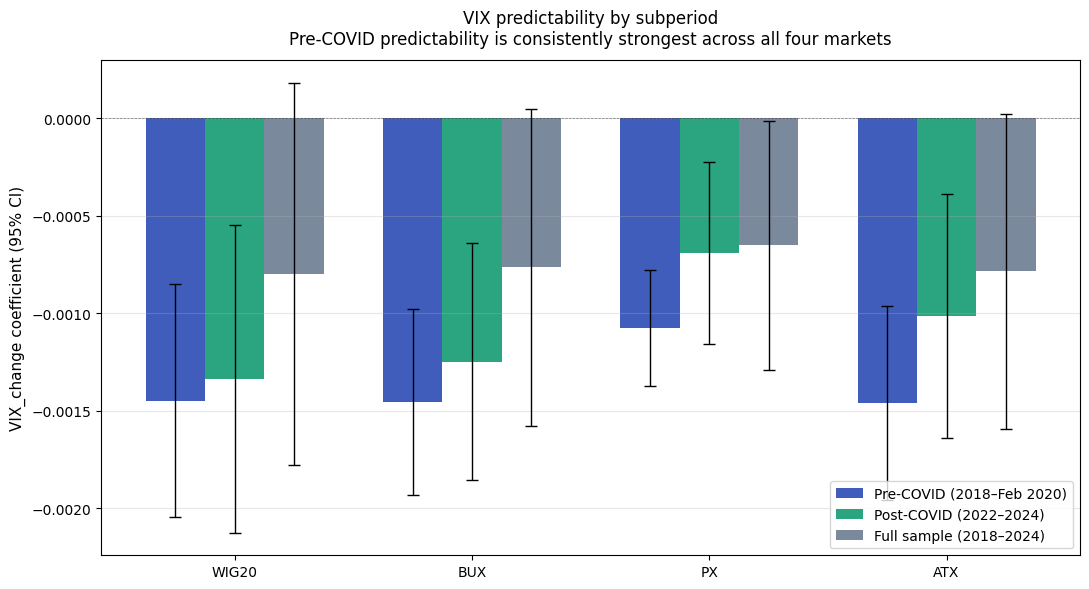

Saved → figures/08_subperiod_coefficients.png


In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

colors_market = {"WIG20": "#2563eb", "BUX": "#7c3aed",
                 "PX": "#059669", "ATX": "#d97706"}

x = np.arange(len(markets))
width = 0.25

pre_coefs   = [pre_results[m].params["VIX_change"]  for m in markets]
post_coefs  = [post_results[m].params["VIX_change"] for m in markets]
full_coefs  = [full_results[m].params["VIX_change"] for m in markets]

pre_err = [
    [c - pre_results[m].conf_int().loc["VIX_change", 0] for c, m in zip(pre_coefs, markets)],
    [pre_results[m].conf_int().loc["VIX_change", 1] - c for c, m in zip(pre_coefs, markets)]
]
post_err = [
    [c - post_results[m].conf_int().loc["VIX_change", 0] for c, m in zip(post_coefs, markets)],
    [post_results[m].conf_int().loc["VIX_change", 1] - c for c, m in zip(post_coefs, markets)]
]
full_err = [
    [c - full_results[m].conf_int().loc["VIX_change", 0] for c, m in zip(full_coefs, markets)],
    [full_results[m].conf_int().loc["VIX_change", 1] - c for c, m in zip(full_coefs, markets)]
]

ax.bar(x - width, pre_coefs,  width, yerr=pre_err,  capsize=4,
       color="#1e40af", alpha=0.85, label="Pre-COVID (2018–Feb 2020)",
       error_kw={"linewidth": 1})
ax.bar(x,         post_coefs, width, yerr=post_err, capsize=4,
       color="#059669", alpha=0.85, label="Post-COVID (2022–2024)",
       error_kw={"linewidth": 1})
ax.bar(x + width, full_coefs, width, yerr=full_err, capsize=4,
       color="#64748b", alpha=0.85, label="Full sample (2018–2024)",
       error_kw={"linewidth": 1})

ax.axhline(0, color="black", linewidth=0.5, linestyle="--", alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(markets, fontsize=11)
ax.set_ylabel("VIX_change coefficient (95% CI)", fontsize=11)
ax.set_title("VIX predictability by subperiod\n"
             "Pre-COVID predictability is consistently strongest across all four markets",
             fontsize=12, fontweight="500", pad=12)
ax.legend(loc="lower right", fontsize=10)
ax.tick_params(labelsize=10)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/08_subperiod_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()